In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

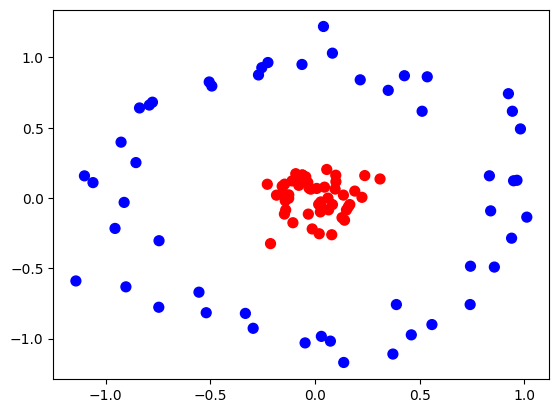

In [41]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.55

In [43]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, 
                                 stop = X_set[:, 0].max() + 1, 
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1, 
                                 stop = X_set[:, 1].max() + 1, 
                                 step = 0.01))
  
    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(), 
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75, 
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipykernel_96096/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


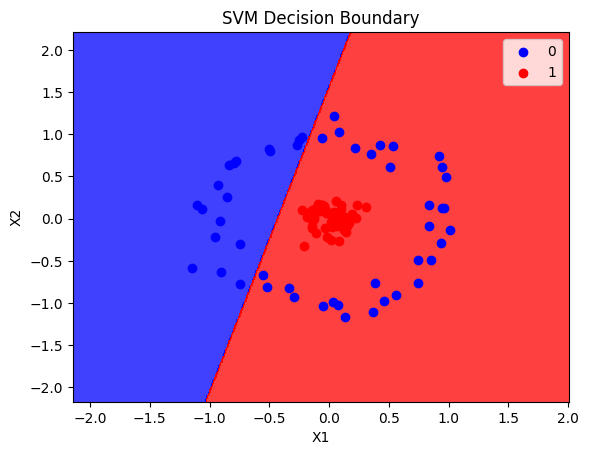

In [44]:
plot_decision_boundary(X, y, classifier)

In [45]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

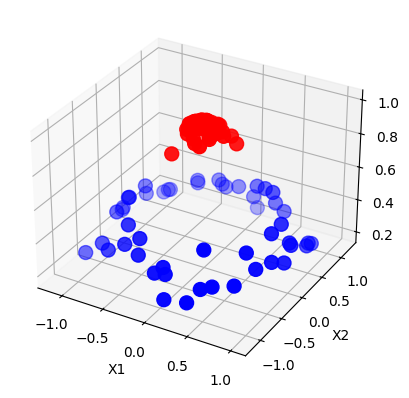

In [46]:
plot_3d_plot(X,y)

In [48]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [49]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_96096/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


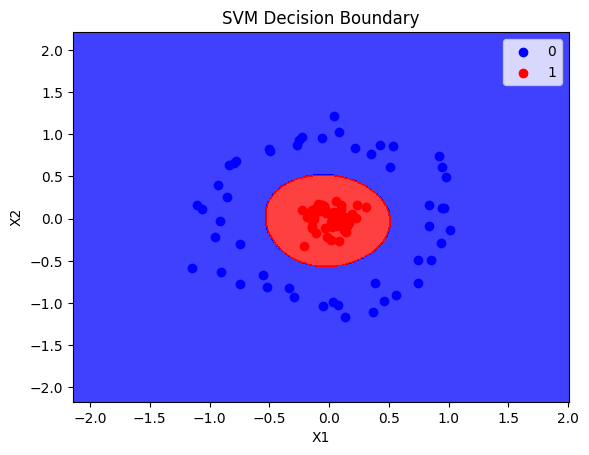

In [50]:
plot_decision_boundary(X, y, rbf_classifier)

In [51]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [52]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_96096/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


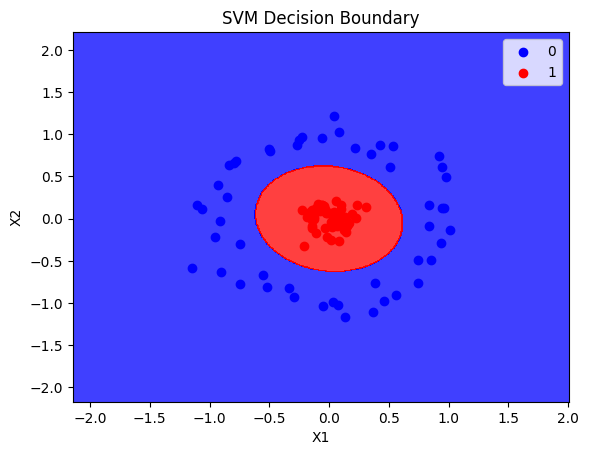

In [53]:
plot_decision_boundary(X, y, poly_classifier)

In [54]:
X

array([[-1.57003433e-01,  8.40719108e-02],
       [ 8.32241300e-02, -4.66110474e-02],
       [-3.44810357e-02,  1.10246772e-01],
       [ 5.59741300e-02,  2.02874363e-01],
       [-1.84273538e-01,  2.01635834e-02],
       [-1.10210649e+00,  1.57427445e-01],
       [ 7.41301177e-01, -7.57804237e-01],
       [ 9.81674280e-01,  4.91283838e-01],
       [-9.21171811e-02,  1.72817201e-01],
       [ 1.50064086e-01, -8.52304449e-02],
       [-1.40296353e-01, -8.49948199e-02],
       [ 9.90616011e-02,  1.62071335e-01],
       [ 7.42921223e-01, -4.85206364e-01],
       [-6.24177775e-02,  9.49863593e-01],
       [ 2.37637679e-01,  1.59489850e-01],
       [-4.93383554e-01,  7.96442365e-01],
       [ 9.43142022e-01,  6.17062894e-01],
       [ 1.58778448e-01, -6.34488014e-02],
       [ 8.56961821e-01, -4.91291093e-01],
       [-2.25183583e-01,  9.63564164e-01],
       [-1.45341955e-01,  9.85075736e-02],
       [ 1.99878009e-02, -2.54329307e-01],
       [ 1.66027003e-01, -4.67683426e-02],
       [-1.

In [55]:
np.exp(-(X**2)).sum(1)

array([1.96860809, 1.99092744, 1.98673098, 1.95654928, 1.96620684,
       1.27233842, 1.14033986, 1.16704368, 1.96212612, 1.97049453,
       1.97331129, 1.96430965, 1.36607101, 1.40177122, 1.91997704,
       1.31423217, 1.09419155, 1.97108688, 1.26535446, 1.34571994,
       1.96944046, 1.93696476, 1.97062659, 1.9795596 , 1.98682288,
       1.95576018, 1.96420114, 1.96956167, 1.33537037, 1.42279638,
       1.99431276, 1.40485343, 1.99201479, 1.99564834, 1.93975482,
       1.00235974, 1.4852914 , 1.98385775, 1.22411471, 0.97681604,
       1.95097077, 1.98284129, 1.97560956, 1.23584242, 1.96213419,
       1.1969494 , 1.99847066, 1.48602111, 1.16243124, 1.98587185,
       1.3025687 , 1.15825628, 1.27746908, 1.98136961, 1.97558879,
       1.95835877, 1.47475353, 1.27675544, 1.41916307, 1.44784412,
       1.34071663, 1.98591597, 1.9276354 , 1.37820852, 1.34938926,
       1.33988115, 1.17663375, 1.39153759, 1.99620168, 1.35527446,
       1.98873175, 1.99766037, 1.22584221, 1.45296624, 1.99266

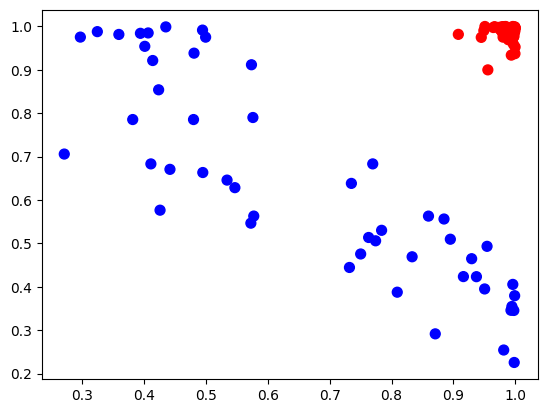

In [56]:
X_new=np.exp(-(X**2))
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='bwr')